# Análisis de Data Drifting y Calidad de Datos

Un desafío común para los **data scientists** en el mundo real es que, a diferencia de las competencias de **Kaggle**, los datos cambian con el tiempo. Esto significa que los datos que recibiremos en el futuro no necesariamente reflejarán los que usamos para entrenar nuestros modelos. Esta homogeneidad es esencial, ya que los algoritmos aprenden patrones en función de las distribuciones observadas durante el entrenamiento. Si esas distribuciones cambian, la capacidad predictiva del modelo se deteriora.

Podemos identificar dos tipos principales de problemáticas asociadas a estos cambios:

- **Data Quality (DQ) - Calidad de Datos**
- **Data Drift (DF) - Deriva de Datos**

Comencemos con el primero: **Data Quality (DQ)**. Hay mucho que decir sobre este tema, pero mencionaremos brevemente que los datos provienen de procesos creados por seres humanos, quienes son propensos a cometer errores y hacer modificaciones. A lo largo del ciclo de vida de los modelos, es común que se enfrenten a este tipo de situaciones. Por ello, es fundamental implementar controles que garanticen que los datos a los que se aplican los modelos mantienen la misma estructura que los datos usados en el entrenamiento.

A continuación, veremos dos indicadores clave para monitorear la calidad de los datos, aunque no son los únicos a considerar.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import lightgbm as lgb

from os import path

In [2]:
base_path = ''
dataset_path = base_path + 'data/'
modelos_path = base_path + 'models/'
db_path = base_path + 'db/'
dataset_file = 'competencia_01.parquet.gzip'

ganancia_acierto = 1_072_500
costo_estimulo = 27_500

data = pd.read_parquet(path.join(dataset_path,dataset_file))

Para este análisis, trabajaremos con un mes de entrenamiento (`mes_train`) y varios meses de puntuación (`meses_score`), donde se realizará la predicción. Es importante destacar que esta lógica es extensible y puede aplicarse a muchos más períodos de entrenamiento y evaluación.

In [3]:
mes_train = 202103
meses_score = [202105, 202106, 202107, 202108]



## Primer Control de Calidad: Análisis de Valores Nulos por Variable

El primer control que implementaremos se enfoca en la cantidad de **valores nulos** por variable. Un incremento en el porcentaje de valores nulos puede ser un indicio temprano de problemas en los procesos de generación de datos o en la captura, impactando la fiabilidad del modelo.

In [4]:
train_data = data[data['foto_mes'] == mes_train]
train_null_percentage = train_data.isnull().mean() * 100

all_comparisons = {}

for mes_score_single in meses_score:
    score_data_single_month = data[data['foto_mes'] == mes_score_single]
    score_null_percentage_single_month = score_data_single_month.isnull().mean() * 100

    comparison_df_single_month = pd.DataFrame({
        'Train Null Percentage': train_null_percentage,
        f'Score Null Percentage {mes_score_single}': score_null_percentage_single_month
    })
    comparison_df_single_month[f'diff_{mes_score_single}'] = (comparison_df_single_month[f'Score Null Percentage {mes_score_single}'] - comparison_df_single_month['Train Null Percentage']).abs()

    all_comparisons[mes_score_single] = comparison_df_single_month.sort_values(f'diff_{mes_score_single}', ascending=False)

# Display results for each month
for mes, df_comp in all_comparisons.items():
    print(f"\nComparison for month {mes}:")
    display(df_comp)


Comparison for month 202105:


,Train Null Percentage,Score Null Percentage 202105,diff_202105
Visa_Finiciomora,99.092081,97.347467,1.744614
Master_mpagospesos,59.852670,59.383396,0.469274
Master_mpagosdolares,59.852670,59.383396,0.469274
Master_cconsumos,59.852670,59.383396,0.469274
Master_cadelantosefectivo,59.852670,59.383396,0.469274
...,...,...,...
mpayroll,0.000000,0.000000,0.000000
mpayroll2,0.000000,0.000000,0.000000
cpayroll2_trx,0.000000,0.000000,0.000000
ccuenta_debitos_automaticos,0.000000,0.000000,0.000000



Comparison for month 202106:


,Train Null Percentage,Score Null Percentage 202106,diff_202106
Master_mpagospesos,59.85267,58.414273,1.438397
Master_mconsumospesos,59.85267,58.414273,1.438397
Master_madelantodolares,59.85267,58.414273,1.438397
Master_mconsumototal,59.85267,58.414273,1.438397
Master_cconsumos,59.85267,58.414273,1.438397
...,...,...,...
mpayroll,0.00000,0.000000,0.000000
mpayroll2,0.00000,0.000000,0.000000
cpayroll2_trx,0.00000,0.000000,0.000000
ccuenta_debitos_automaticos,0.00000,0.000000,0.000000



Comparison for month 202107:


,Train Null Percentage,Score Null Percentage 202107,diff_202107
clase_ternaria,0.00000,99.328863,99.328863
Master_mpagosdolares,59.85267,57.898484,1.954187
Master_cconsumos,59.85267,57.898484,1.954187
Master_cadelantosefectivo,59.85267,57.898484,1.954187
Master_mpagospesos,59.85267,57.898484,1.954187
...,...,...,...
mpayroll,0.00000,0.000000,0.000000
mpayroll2,0.00000,0.000000,0.000000
cpayroll2_trx,0.00000,0.000000,0.000000
ccuenta_debitos_automaticos,0.00000,0.000000,0.000000



Comparison for month 202108:


,Train Null Percentage,Score Null Percentage 202108,diff_202108
clase_ternaria,0.000000,100.000000,100.000000
Visa_Finiciomora,99.092081,97.471560,1.620521
Master_mpagosdolares,59.852670,58.303522,1.549148
Master_madelantodolares,59.852670,58.303522,1.549148
Master_mconsumototal,59.852670,58.303522,1.549148
...,...,...,...
mpayroll,0.000000,0.000000,0.000000
mpayroll2,0.000000,0.000000,0.000000
cpayroll2_trx,0.000000,0.000000,0.000000
ccuenta_debitos_automaticos,0.000000,0.000000,0.000000


## Segundo Control de Calidad: Análisis de la Proporción de Ceros

Un problema similar a los valores nulos es la **sobrerrepresentación de ceros** en los datos. Dado que el valor cero se utiliza comúnmente para la imputación o como valor por defecto, una acumulación excesiva de ceros puede ser indicativa de un error en la fuente de datos o de un proceso de imputación inadecuado, afectando la validez y el significado de la variable.

In [5]:
train_zero_percentage = (train_data == 0).mean() * 100

all_zero_comparisons = {}

for mes_score_single in meses_score:
    score_data_single_month = data[data['foto_mes'] == mes_score_single]
    score_zero_percentage_single_month = (score_data_single_month == 0).mean() * 100

    comparison_df_zero_single_month = pd.DataFrame({
        'Train Zero Percentage': train_zero_percentage,
        f'Score Zero Percentage {mes_score_single}': score_zero_percentage_single_month
    })

    comparison_df_zero_single_month[f'diff_zero_percentage_{mes_score_single}'] = \
        (comparison_df_zero_single_month[f'Score Zero Percentage {mes_score_single}'] - comparison_df_zero_single_month['Train Zero Percentage']).abs()

    all_zero_comparisons[mes_score_single] = comparison_df_zero_single_month.sort_values(f'diff_zero_percentage_{mes_score_single}',ascending=False)

# Display results for each month
for mes, df_comp_zero in all_zero_comparisons.items():
    print(f"\nZero Percentage Comparison for month {mes}:")
    display(df_comp_zero)


Zero Percentage Comparison for month 202105:


,Train Zero Percentage,Score Zero Percentage 202105,diff_zero_percentage_202105
Visa_mpagado,86.675261,69.676005,16.999256
ctarjeta_visa_debitos_automaticos,42.927563,36.709247,6.218316
mttarjeta_visa_debitos_automaticos,42.927563,36.709247,6.218316
ccajas_depositos,96.018416,100.000000,3.981584
matm_other,75.542664,79.497826,3.955162
...,...,...,...
tcuentas,0.000000,0.000000,0.000000
cproductos,0.000000,0.000000,0.000000
cliente_antiguedad,0.000000,0.000000,0.000000
cliente_edad,0.000000,0.000000,0.000000



Zero Percentage Comparison for month 202106:


,Train Zero Percentage,Score Zero Percentage 202106,diff_zero_percentage_202106
Master_fultimo_cierre,0.000000,69.090388,69.090388
Visa_fultimo_cierre,0.000000,69.036767,69.036767
ctarjeta_visa_debitos_automaticos,42.927563,36.682428,6.245135
mttarjeta_visa_debitos_automaticos,42.927563,36.682428,6.245135
cmobile_app_trx,28.808471,23.790780,5.017692
...,...,...,...
tcuentas,0.000000,0.000000,0.000000
cproductos,0.000000,0.000000,0.000000
cliente_antiguedad,0.000000,0.000000,0.000000
cliente_edad,0.000000,0.000000,0.000000



Zero Percentage Comparison for month 202107:


,Train Zero Percentage,Score Zero Percentage 202107,diff_zero_percentage_202107
mttarjeta_visa_debitos_automaticos,42.927563,35.033587,7.893976
ctarjeta_visa_debitos_automaticos,42.927563,35.033587,7.893976
cmobile_app_trx,28.808471,21.817728,6.990743
mcuenta_corriente,48.726826,52.505659,3.778832
mforex_sell,95.834868,92.141675,3.693193
...,...,...,...
tcuentas,0.000000,0.000000,0.000000
cproductos,0.000000,0.000000,0.000000
cliente_antiguedad,0.000000,0.000000,0.000000
cliente_edad,0.000000,0.000000,0.000000



Zero Percentage Comparison for month 202108:


,Train Zero Percentage,Score Zero Percentage 202108,diff_zero_percentage_202108
Visa_mpagado,86.675261,69.161297,17.513964
mttarjeta_visa_debitos_automaticos,42.927563,34.949316,7.978247
ctarjeta_visa_debitos_automaticos,42.927563,34.949316,7.978247
cmobile_app_trx,28.808471,21.043809,7.764663
cforex_sell,95.834868,92.191780,3.643088
...,...,...,...
tcuentas,0.000000,0.000000,0.000000
cproductos,0.000000,0.000000,0.000000
cliente_antiguedad,0.000000,0.000000,0.000000
cliente_edad,0.000000,0.000000,0.000000


La segunda problemática que abordaremos es el **Data Drift**, un fenómeno que ocurre cuando la distribución de los datos cambia con el tiempo. Esta deriva puede impactar significativamente el rendimiento de los modelos predictivos.

### Tipos de Data Drift:

1.  **Feature Drift**: Se produce cuando la distribución de una característica específica (feature) del modelo cambia a lo largo del tiempo.

2.  **Concept Drift**: Sucede cuando la relación entre las características (features) y la variable objetivo (target) se altera. Por ejemplo, en un modelo de detección de fraude, los patrones de comportamiento fraudulento pueden evolucionar, requiriendo que el modelo se adapte para reconocer estas nuevas dinámicas.

Para detectar el Data Drift, utilizaremos el **Índice de Estabilidad de Población (PSI - Population Stability Index)**. El PSI es una métrica robusta diseñada para cuantificar cambios en la distribución de una variable a lo largo del tiempo, comparando típicamente una distribución de referencia (e.g., datos de entrenamiento) con una distribución observada (e.g., datos actuales).

### Funcionamiento del PSI:

1.  **División en Intervalos (Bins)**: Tanto los datos históricos como los datos actuales se dividen en una serie de intervalos o *bins*.

2.  **Cálculo de Frecuencias**: Se calcula la proporción de observaciones que caen en cada bin, tanto para la distribución original (entrenamiento) como para la nueva (actual).

3.  **Fórmula del PSI**: Para cada bin, se calcula la diferencia entre las frecuencias observadas en ambas distribuciones mediante la siguiente fórmula:

    $$\text{PSI} = \sum \left( (P_{\text{actual}} - P_{\text{esperado}}) \times \log \left( \frac{P_{\text{actual}}}{P_{\text{esperado}}} \right) \right)$$
    Donde:
    -   $P_{\text{actual}}$ es la proporción de la nueva muestra en un bin.
    -   $P_{\text{esperado}}$ es la proporción de la muestra original en el mismo bin.

## Interpretación de los Valores PSI:

-   **PSI bajo (ej. < 0.1)**: Indica que la distribución de la variable en los datos actuales es muy similar a la distribución de los datos esperados. Es una buena señal, sugiere que no hay un drifting significativo y que el modelo debería seguir funcionando bien con esta variable.

-   **PSI moderado (ej. 0.1 a 0.25)**: Sugiere que hay una ligera desviación en la distribución. Esto podría ser una señal de advertencia temprana. Si bien el impacto en el rendimiento del modelo podría ser menor inicialmente, es recomendable investigar la causa y monitorear la variable de cerca.

-   **PSI alto (ej. > 0.25)**: Indica un cambio significativo o un drifting sustancial en la distribución de la variable. Esto es una señal de alerta y probablemente tendrá un impacto negativo considerable en la precisión del modelo.

In [6]:
import pandas as pd
import numpy as np

def _calculate_psi_term(expected_prop, actual_prop, epsilon):
    """Helper to calculate (actual - expected) * log(actual/expected) safely."""
    expected_prop_safe = np.maximum(expected_prop, epsilon)
    actual_prop_safe = np.maximum(actual_prop, epsilon)
    # Handle cases where actual_prop_safe is zero when expected_prop_safe is not
    # This results in log(0) which is -inf, making the term -inf or inf
    # In PSI, if actual_prop is 0 and expected_prop is > 0, it means an entire bin disappeared,
    # which is significant drift. We'll let this propagate or handle as inf later.
    log_ratio = np.log(actual_prop_safe / expected_prop_safe)
    return (actual_prop - expected_prop) * log_ratio

def psi(expected, actual, buckets=10, custom_thresholds=None):
    epsilon = 1e-10

    # If both are empty, no drift
    if expected.empty and actual.empty:
        return 0.0

    # Use psi_bins to get the binned proportions
    comparison_df = psi_bins(expected, actual, buckets=buckets, custom_thresholds=custom_thresholds)

    # Extract proportions from the comparison DataFrame
    expected_props = comparison_df['Expected_Prop'].values
    actual_props = comparison_df['Actual_Prop'].values

    # Calculate PSI term for each bin using the helper function
    psi_terms = _calculate_psi_term(expected_props, actual_props, epsilon)

    # Sum all terms to get the total PSI
    total_psi = np.sum(psi_terms)

    # Return inf if NaN results from some edge cases (e.g., 0*log(0))
    return total_psi if not np.isnan(total_psi) else np.inf

def psi_bins(expected, actual, buckets=10, custom_thresholds=None):
    epsilon = 1e-10

    # Initialize lists to store bin data
    bin_labels = []
    expected_counts_list = []
    actual_counts_list = []
    expected_prop_list = []
    actual_prop_list = []

    # Handle non-null values
    expected_not_null = expected.dropna()
    actual_not_null = actual.dropna()

    breakpoints = []

    if custom_thresholds is not None and len(custom_thresholds) >= 2:
        # Use custom thresholds if provided and valid
        breakpoints = sorted(list(set(custom_thresholds)))

        # Ensure min/max values from the data are covered by the custom thresholds
        min_val = np.inf
        if not expected_not_null.empty: min_val = min(min_val, expected_not_null.min())
        if not actual_not_null.empty: min_val = min(min_val, actual_not_null.min())

        max_val = -np.inf
        if not expected_not_null.empty: max_val = max(max_val, expected_not_null.max())
        if not actual_not_null.empty: max_val = max(max_val, actual_not_null.max())

        if min_val != np.inf and breakpoints[0] > min_val: breakpoints.insert(0, min_val)
        if max_val != -np.inf and breakpoints[-1] < max_val: breakpoints.append(max_val)
        breakpoints = sorted(list(set(breakpoints))) # Re-sort after adding min/max

    elif not expected_not_null.empty or not actual_not_null.empty:
        # Determine breakpoints from the union of non-null expected and actual values using qcut
        all_non_null_values = pd.concat([expected_not_null, actual_not_null])
        if all_non_null_values.nunique() > 1: # Needs at least 2 unique values for qcut
            try:
                _, bin_edges = pd.qcut(all_non_null_values, q=buckets, duplicates='drop', retbins=True)
                breakpoints = sorted(list(set(bin_edges)))

                min_val = np.inf
                if not expected_not_null.empty: min_val = min(min_val, expected_not_null.min())
                if not actual_not_null.empty: min_val = min(min_val, actual_not_null.min())

                max_val = -np.inf
                if not expected_not_null.empty: max_val = max(max_val, expected_not_null.max())
                if not actual_not_null.empty: max_val = max(max_val, actual_not_null.max())

                if min_val != np.inf and breakpoints[0] > min_val: breakpoints.insert(0, min_val)
                if max_val != -np.inf and breakpoints[-1] < max_val: breakpoints.append(max_val)
                breakpoints = sorted(list(set(breakpoints))) # Re-sort after adding min/max
            except ValueError:
                # Fallback for qcut issues (e.g., many identical values)
                if all_non_null_values.nunique() == 1:
                    val = all_non_null_values.iloc[0]
                    breakpoints = [val - 1, val + 1]
                else: # Generic fallback for few unique values
                    min_val = all_non_null_values.min()
                    max_val = all_non_null_values.max()
                    if min_val == max_val: breakpoints = [min_val - 1, min_val + 1]
                    else: breakpoints = [min_val, max_val]
        elif all_non_null_values.nunique() == 1 and not all_non_null_values.empty:
            val = all_non_null_values.iloc[0]
            breakpoints = [val - 1, val + 1] # Single bin around the unique value
    # If no non-null data in either, breakpoints remains empty, handled by len(breakpoints) < 2


    if len(breakpoints) >= 2:
        expected_counts, _ = np.histogram(expected_not_null, bins=breakpoints)
        actual_counts, _ = np.histogram(actual_not_null, bins=breakpoints)

        total_expected_not_null = len(expected_not_null)
        total_actual_not_null = len(actual_not_null)

        for i in range(len(breakpoints) - 1):
            bin_labels.append(f"({breakpoints[i]:.3f}, {breakpoints[i+1]:.3f}]")
            expected_counts_list.append(expected_counts[i])
            actual_counts_list.append(actual_counts[i])
            expected_prop_list.append(expected_counts[i] / total_expected_not_null if total_expected_not_null > 0 else 0.0)
            actual_prop_list.append(actual_counts[i] / total_actual_not_null if total_actual_not_null > 0 else 0.0)

    # Handle null values
    expected_null_count = expected.isnull().sum()
    actual_null_count = actual.isnull().sum()
    expected_total = len(expected)
    actual_total = len(actual)

    expected_null_prop = expected_null_count / expected_total if expected_total > 0 else 0.0
    actual_null_prop = actual_null_count / actual_total if actual_total > 0 else 0.0

    bin_labels.append('Null_Values')
    expected_counts_list.append(expected_null_count)
    actual_counts_list.append(actual_null_count)
    expected_prop_list.append(expected_null_prop)
    actual_prop_list.append(actual_null_prop)

    comparison_df = pd.DataFrame({
        'Bin': bin_labels,
        'Expected_Counts': expected_counts_list,
        'Actual_Counts': actual_counts_list,
        'Expected_Prop': expected_prop_list,
        'Actual_Prop': actual_prop_list
    })
    return comparison_df

### Ejemplo Práctico: Visualización de Bins con PSI

Analicemos un ejemplo práctico de cómo se distribuyen los datos en sus respectivos bins para una variable específica, utilizando la función `psi_bins_comparison`.

In [7]:
variable_name_to_compare = 'mprestamos_personales'
expected_data_for_bins = train_data[variable_name_to_compare]
actual_data_for_bins = data[data['foto_mes'] == 202106][variable_name_to_compare]

bins_mprestamos = psi_bins(expected_data_for_bins, actual_data_for_bins, buckets=10)
bins_mprestamos


,Bin,Expected_Counts,Actual_Counts,Expected_Prop,Actual_Prop
0,"(0.000, 10956.868]",130257,131354,0.799613,0.800383
1,"(10956.868, 97496.025]",16660,16041,0.102271,0.097743
2,"(97496.025, 7038000.000]",15983,16719,0.098115,0.101874
3,Null_Values,0,0,0.000000,0.000000


In [8]:
psi(expected_data_for_bins, actual_data_for_bins)

np.float64(0.00034713238408232426)

Ya vimos cómo el PSI reparte a `mprestamos_personales` en esos mismos bins (arriba). Ahora, usando esos **mismos intervalos**, miremos cuánto target (BAJA+2) cae en cada uno, Marzo (`train_data`, la referencia del PSI) contra Junio (`202106`, la muestra actual).

In [9]:
numeric_bins_mprestamos = bins_mprestamos[bins_mprestamos['Bin'] != 'Null_Values']

parsed_edges = []
for bin_str in numeric_bins_mprestamos['Bin'].tolist():
    parts = bin_str[1:-1].split(', ')
    parsed_edges.append(float(parts[0]))
    parsed_edges.append(float(parts[1]))
cortes_mprestamos = sorted(set(parsed_edges))

score_data_202106 = data[data['foto_mes'] == 202106]

train_bin = pd.cut(train_data[variable_name_to_compare], bins=cortes_mprestamos, right=True, include_lowest=True)
score_bin = pd.cut(score_data_202106[variable_name_to_compare], bins=cortes_mprestamos, right=True, include_lowest=True)

train_target = (train_data['clase_ternaria'] == 'BAJA+2').astype(int)
score_target = (score_data_202106['clase_ternaria'] == 'BAJA+2').astype(int)

target_por_bin_psi = pd.DataFrame({
    'count_train': train_target.groupby(train_bin, observed=False).count(),
    'target_train': train_target.groupby(train_bin, observed=False).sum(),
    'count_202106': score_target.groupby(score_bin, observed=False).count(),
    'target_202106': score_target.groupby(score_bin, observed=False).sum(),
})
target_por_bin_psi


,count_train,target_train,count_202106,target_202106
mprestamos_personales,,,,
"(-0.001, 10956.868]",130257,894,131354,887
"(10956.868, 97496.025]",16660,49,16041,87
"(97496.025, 7038000.0]",15983,17,16719,124


En el bin más alto (préstamos personales entre ~$97.496 y el máximo), la población es parecida entre los dos meses (15.983 vs 16.719 — coherente con que el PSI de esta variable da bajísimo), pero el conteo de BAJA+2 pasa de **17 a 124**, más de 7 veces. Es la misma idea que separa el PSI (drift de población) del drift de target: acá los bins del PSI no se movieron, pero lo que le pasa a la gente dentro del bin más alto sí.

### Aplicación del Análisis de PSI a Múltiples Variables

Ahora aplicaremos el análisis de PSI a (casi) todas las variables (features) de nuestro *dataset*. Esto nos permitirá identificar qué características presentan mayor *drift* entre los datos de entrenamiento y los diferentes meses de puntuación.

In [10]:
all_psi_results = {}

for mes_score_single in meses_score:
    psi_results_for_month = []
    current_score_data = data[data['foto_mes'] == mes_score_single]

    for column in train_data.columns:
        if column not in ['foto_mes', 'clase_ternaria', 'ctarjeta_master_descuentos','mtarjeta_master_descuentos','mtarjeta_visa_descuentos','ctarjeta_visa_descuentos','ccajeros_propios_descuentos','mcajeros_propios_descuentos']:
            train_variable = train_data[column]
            score_variable = current_score_data[column]
            psi_value = psi(train_variable, score_variable)
            psi_results_for_month.append({'feature': column, 'psi': psi_value})

    psi_df_for_month = pd.DataFrame(psi_results_for_month)
    psi_df_for_month = psi_df_for_month.sort_values('psi', ascending=False)
    all_psi_results[mes_score_single] = psi_df_for_month

# Display results for each month
for mes, df_psi in all_psi_results.items():
    print(f"\nPSI Results for month {mes}:")
    display(df_psi)


PSI Results for month 202105:


,feature,psi
116,Master_fultimo_cierre,38.583114
138,Visa_fultimo_cierre,37.618317
107,Master_Finiciomora,4.161409
129,Visa_Finiciomora,3.512589
139,Visa_mpagado,0.119152
...,...,...
82,mcheques_emitidos,0.000000
81,ccheques_emitidos,0.000000
80,mcheques_depositados,0.000000
79,ccheques_depositados,0.000000



PSI Results for month 202106:


,feature,psi
116,Master_fultimo_cierre,34.964590
138,Visa_fultimo_cierre,32.923122
129,Visa_Finiciomora,5.390300
107,Master_Finiciomora,2.722687
51,mpayroll,0.232233
...,...,...
102,cmobile_app_trx,0.000000
36,mprestamos_hipotecarios,0.000000
35,cprestamos_hipotecarios,0.000000
34,mprestamos_prendarios,0.000000



PSI Results for month 202107:


,feature,psi
116,Master_fultimo_cierre,38.631139
138,Visa_fultimo_cierre,37.691113
129,Visa_Finiciomora,4.508355
107,Master_Finiciomora,3.267643
65,mcomisiones_mantenimiento,0.547378
...,...,...
84,mcheques_depositados_rechazados,0.000000
83,ccheques_depositados_rechazados,0.000000
36,mprestamos_hipotecarios,0.000000
82,mcheques_emitidos,0.000000



PSI Results for month 202108:


,feature,psi
116,Master_fultimo_cierre,38.597349
138,Visa_fultimo_cierre,37.657892
107,Master_Finiciomora,6.284393
129,Visa_Finiciomora,5.374902
65,mcomisiones_mantenimiento,0.660497
...,...,...
85,ccheques_emitidos_rechazados,0.000000
84,mcheques_depositados_rechazados,0.000000
83,ccheques_depositados_rechazados,0.000000
82,mcheques_emitidos,0.000000


### ¿Cambia la proporción de target dentro de los bins del PSI?

El PSI de la sección anterior mide si cambió **cuánta gente** cae en cada bin. No dice nada sobre si esa gente se sigue dando de baja al mismo ritmo. Usando esos **mismos bins** (los que arma `qcut` para cada variable), calculamos ahora la tasa de BAJA+2 dentro de cada bin en Marzo (`train_data`) contra cada mes de score, y nos quedamos con el mayor movimiento de tasa entre bins, por variable. Una variable puede tener PSI bajo (la población no se mueve de bin) y aun así tener un bin donde el target se comporta distinto.

In [11]:
def psi_target_bins(expected, actual, expected_class, actual_class, buckets=10, clase_positiva='BAJA+2'):
    """Con los mismos bins que usaría psi_bins() (qcut sobre expected+actual), compara la tasa
    de `clase_positiva` dentro de cada bin entre expected y actual. Devuelve None si la variable
    no tiene suficiente variabilidad para formar bins (mismo caso borde que maneja psi_bins()).
    """
    expected_not_null = expected.dropna()
    actual_not_null = actual.dropna()

    all_non_null_values = pd.concat([expected_not_null, actual_not_null])
    if all_non_null_values.nunique() <= 1:
        return None

    try:
        _, bin_edges = pd.qcut(all_non_null_values, q=buckets, duplicates='drop', retbins=True)
    except ValueError:
        return None

    breakpoints = sorted(set(bin_edges))
    if len(breakpoints) < 2:
        return None

    expected_bin = pd.cut(expected_not_null, bins=breakpoints, include_lowest=True)
    actual_bin = pd.cut(actual_not_null, bins=breakpoints, include_lowest=True)

    expected_target = (expected_class.loc[expected_not_null.index] == clase_positiva).astype(int)
    actual_target = (actual_class.loc[actual_not_null.index] == clase_positiva).astype(int)

    resumen = pd.DataFrame({
        'count_expected': expected_target.groupby(expected_bin, observed=False).count(),
        'target_expected': expected_target.groupby(expected_bin, observed=False).sum(),
        'count_actual': actual_target.groupby(actual_bin, observed=False).count(),
        'target_actual': actual_target.groupby(actual_bin, observed=False).sum(),
    })
    resumen['tasa_expected'] = resumen['target_expected'] / resumen['count_expected']
    resumen['tasa_actual'] = resumen['target_actual'] / resumen['count_actual']
    resumen['diff_tasa'] = resumen['tasa_actual'] - resumen['tasa_expected']
    return resumen


In [12]:
all_target_shift_results = {}

for mes_score_single in meses_score:
    target_shift_for_month = []
    current_score_data = data[data['foto_mes'] == mes_score_single]

    for column in train_data.columns:
        if column not in ['foto_mes', 'clase_ternaria', 'ctarjeta_master_descuentos','mtarjeta_master_descuentos','mtarjeta_visa_descuentos','ctarjeta_visa_descuentos','ccajeros_propios_descuentos','mcajeros_propios_descuentos']:
            resumen = psi_target_bins(
                train_data[column], current_score_data[column],
                train_data['clase_ternaria'], current_score_data['clase_ternaria']
            )
            if resumen is None:
                continue
            target_shift_for_month.append({
                'feature': column,
                'max_diff_tasa_objetivo': resumen['diff_tasa'].abs().max()
            })

    target_shift_df_for_month = pd.DataFrame(target_shift_for_month)
    target_shift_df_for_month = target_shift_df_for_month.sort_values('max_diff_tasa_objetivo', ascending=False)
    all_target_shift_results[mes_score_single] = target_shift_df_for_month

# Display results for each month
for mes, df_shift in all_target_shift_results.items():
    print(f"\nCambio de proporción de target dentro de los bins del PSI - mes {mes}:")
    display(df_shift)



Cambio de proporción de target dentro de los bins del PSI - mes 202105:


,feature,max_diff_tasa_objetivo
107,Master_Finiciomora,0.058644
48,cseguro_accidentes_personales,0.018519
129,Visa_Finiciomora,0.017436
14,mcuenta_corriente_adicional,0.013889
65,mcomisiones_mantenimiento,0.010417
...,...,...
114,Master_madelantopesos,0.000133
112,Master_mconsumosdolares,0.000133
136,Visa_madelantopesos,0.000122
137,Visa_madelantodolares,0.000122



Cambio de proporción de target dentro de los bins del PSI - mes 202106:


,feature,max_diff_tasa_objetivo
107,Master_Finiciomora,0.067949
129,Visa_Finiciomora,0.047619
14,mcuenta_corriente_adicional,0.013889
31,cprestamos_personales,0.013324
67,mcomisiones_otras,0.008855
...,...,...
114,Master_madelantopesos,0.000012
119,Master_mpagosdolares,0.000012
115,Master_madelantodolares,0.000012
123,Master_cadelantosefectivo,0.000012



Cambio de proporción de target dentro de los bins del PSI - mes 202107:


,feature,max_diff_tasa_objetivo
107,Master_Finiciomora,0.081633
129,Visa_Finiciomora,0.047619
100,ctrx_quarter,0.033588
17,mcaja_ahorro,0.028374
10,mpasivos_margen,0.027810
...,...,...
123,Master_cadelantosefectivo,0.002523
115,Master_madelantodolares,0.002523
114,Master_madelantopesos,0.002523
112,Master_mconsumosdolares,0.002523



Cambio de proporción de target dentro de los bins del PSI - mes 202108:


,feature,max_diff_tasa_objetivo
107,Master_Finiciomora,0.081633
100,ctrx_quarter,0.033588
129,Visa_Finiciomora,0.030864
17,mcaja_ahorro,0.028635
10,mpasivos_margen,0.027905
...,...,...
123,Master_cadelantosefectivo,0.002523
115,Master_madelantodolares,0.002523
114,Master_madelantopesos,0.002523
112,Master_mconsumosdolares,0.002523


`Master_Finiciomora` y `Visa_Finiciomora` vuelven a aparecer arriba de todo — ya las habíamos marcado como las de mayor PSI (drift poblacional) en la sección anterior, así que acá además arrastran el problema al target: no solo cambia cuánta gente cae en cada bin, sino cuánto se dan de baja los que caen ahí. `mprestamos_personales`, en cambio, tiene PSI bajo pero igual aparece en el ranking (no en el primer puesto): su población casi no se mueve entre meses, pero la tasa de BAJA+2 en su bin más alto sí — el mismo caso que vimos en detalle unas celdas más arriba.

### Análisis Detallado de Variables con Drifting Significativo

Hemos identificado un par de variables problemáticas, **Master_Finiciomora** y **Visa_Finiciomora**, que muestran cambios significativos en su distribución para el mes de **202105**. Realizaremos un análisis detallado (*deep dive*) para comprender las causas de este *drifting*.

In [13]:
variable_name_to_compare = 'Master_Finiciomora'
expected_data_for_bins = train_data[variable_name_to_compare]
actual_data_for_bins = data[data['foto_mes'] == 202105][variable_name_to_compare]

psi_bins(expected_data_for_bins, actual_data_for_bins, buckets=10)


,Bin,Expected_Counts,Actual_Counts,Expected_Prop,Actual_Prop
0,"(1.000, 9.000]",135,38,0.119787,0.046455
1,"(9.000, 16.000]",129,54,0.114463,0.066015
2,"(16.000, 21.000]",566,23,0.502218,0.028117
3,"(21.000, 23.000]",6,373,0.005324,0.455990
4,"(23.000, 49.000]",79,63,0.070098,0.077017
5,"(49.000, 51.000]",11,180,0.009760,0.220049
6,"(51.000, 230.000]",201,87,0.178350,0.106357
7,Null_Values,161773,162950,0.993082,0.995005


### Observaciones

*¿Qué sucedió con estas variables y cómo podría abordarse esta situación?*

Además de estos hallazgos, notamos que otras variables ya mostraron indicios de drift en detecciones previas. Específicamente, observamos un cambio relevante en las variables relacionadas con **'payroll'** para el mes de **202106**. A continuación, profundizaremos en este caso.

In [14]:
variable_name_to_compare = 'cpayroll_trx'
expected_data_for_bins = train_data[variable_name_to_compare]
actual_data_for_bins = data[data['foto_mes'] == 202106][variable_name_to_compare]

bins = psi_bins(expected_data_for_bins, actual_data_for_bins, buckets=10)
bins

,Bin,Expected_Counts,Actual_Counts,Expected_Prop,Actual_Prop
0,"(0.000, 1.000]",74880,73414,0.459669,0.447335
1,"(1.000, 2.000]",50185,26648,0.308072,0.162375
2,"(2.000, 3.000]",24410,38600,0.149847,0.235202
3,"(3.000, 138.000]",13425,25452,0.082413,0.155087
4,Null_Values,0,0,0.000000,0.000000


### Análisis de Puntos de Corte del Modelo LightGBM

Antes de tomar una decisión final sobre cómo manejar el *drift* en las variables, es crucial entender cómo los modelos **LightGBM (LGBM)** las utilizan. Para ello, cargaremos nuestro modelo entrenado y analizaremos los **puntos de corte (split points)** que ha definido para cada variable. Esto nos dará información valiosa sobre cómo el modelo segmenta los datos.

In [15]:
# Cargo un modelo previamente entrenado y guardado en txt
model_marzo = lgb.Booster(model_file='models/lgb_train_202103.txt')
model_abril = lgb.Booster(model_file='models/lgb_train_202104.txt')


Y analizo sus cortes

In [16]:
model_df = model_marzo.trees_to_dataframe()

In [17]:
model_df[model_df['split_feature'] == 'cpayroll_trx'].sort_values('threshold')

,tree_index,node_depth,node_index,left_child,right_child,parent_index,split_feature,split_gain,threshold,decision_type,missing_direction,missing_type,value,weight,count
16,0,2,0-S5,0-S6,0-L6,0-S0,cpayroll_trx,246.514999,1.000000e-35,<=,left,None,-5.137860,860.98800,146965
4061,131,1,131-S0,131-S3,131-S1,NaN,cpayroll_trx,29.802700,1.000000e-35,<=,left,None,-0.000071,919.50500,162900
4247,137,1,137-S0,137-S2,137-S1,NaN,cpayroll_trx,27.259800,1.000000e-35,<=,left,None,-0.000067,918.34900,162900
4278,138,1,138-S0,138-S1,138-S5,NaN,cpayroll_trx,26.264601,1.000000e-35,<=,left,None,-0.000066,918.22200,162900
4402,142,1,142-S0,142-S1,142-S2,NaN,cpayroll_trx,23.997499,1.000000e-35,<=,left,None,-0.000064,917.50000,162900
4805,155,1,155-S0,155-S7,155-S1,NaN,cpayroll_trx,20.014900,1.000000e-35,<=,left,None,-0.000057,915.67400,162900
4836,156,1,156-S0,156-S2,156-S1,NaN,cpayroll_trx,19.274599,1.000000e-35,<=,left,None,-0.000056,915.49400,162900
4867,157,1,157-S0,157-S1,157-S3,NaN,cpayroll_trx,18.553900,1.000000e-35,<=,left,None,-0.000056,915.38900,162900
5211,168,4,168-S10,168-S11,168-L11,168-S8,cpayroll_trx,6.920650,1.000000e-35,<=,left,None,0.003726,251.59500,21779
5239,169,1,169-S0,169-S1,169-S6,NaN,cpayroll_trx,14.985300,1.000000e-35,<=,left,None,-0.000050,913.78200,162900


¿Cuáles son los valores de corte (*thresholds*) que el modelo LightGBM utiliza para la variable **cpayroll_trx**?

In [18]:
model_df_cpayroll = model_df[model_df['split_feature'] == 'cpayroll_trx'].copy()

numeric_bins_df = bins[bins['Bin'] != 'Null_Values']

parsed_edges = []
for bin_str in numeric_bins_df['Bin'].tolist():
    parts = bin_str[1:-1].split(', ')
    parsed_edges.append(float(parts[0]))
    parsed_edges.append(float(parts[1]))

bin_edges_for_cut = sorted(list(set(parsed_edges)))

# Asignar cada threshold a su bin y luego agrupar
model_df_cpayroll['bin_category'] = pd.cut(model_df_cpayroll['threshold'],
                                             bins=bin_edges_for_cut,
                                             right=True,
                                             include_lowest=True)

# Agrupar por bin y calcular el conteo de thresholds, suma de gain, suma de casos y promedio de profundidad
cpayroll_trx_detailed_summary = model_df_cpayroll.groupby('bin_category', observed=False).agg(
    threshold_count=('threshold', 'count'),
    total_gain=('split_gain', 'sum'),
    total_cases=('count', 'sum'), # 'count' column in model_df represents cases
    avg_depth=('node_depth', 'mean') # Add average depth
).sort_index()

display(cpayroll_trx_detailed_summary)

,threshold_count,total_gain,total_cases,avg_depth
bin_category,,,,
"(-0.001, 1.0]",48,3815.778238,7238697,1.270833
"(1.0, 2.0]",3,28.157370,8423,5.666667
"(2.0, 3.0]",0,0.000000,0,NaN
"(3.0, 138.0]",0,0.000000,0,NaN


Dibujamos el árbol con un de los que parece tener conflico

<Axes: >

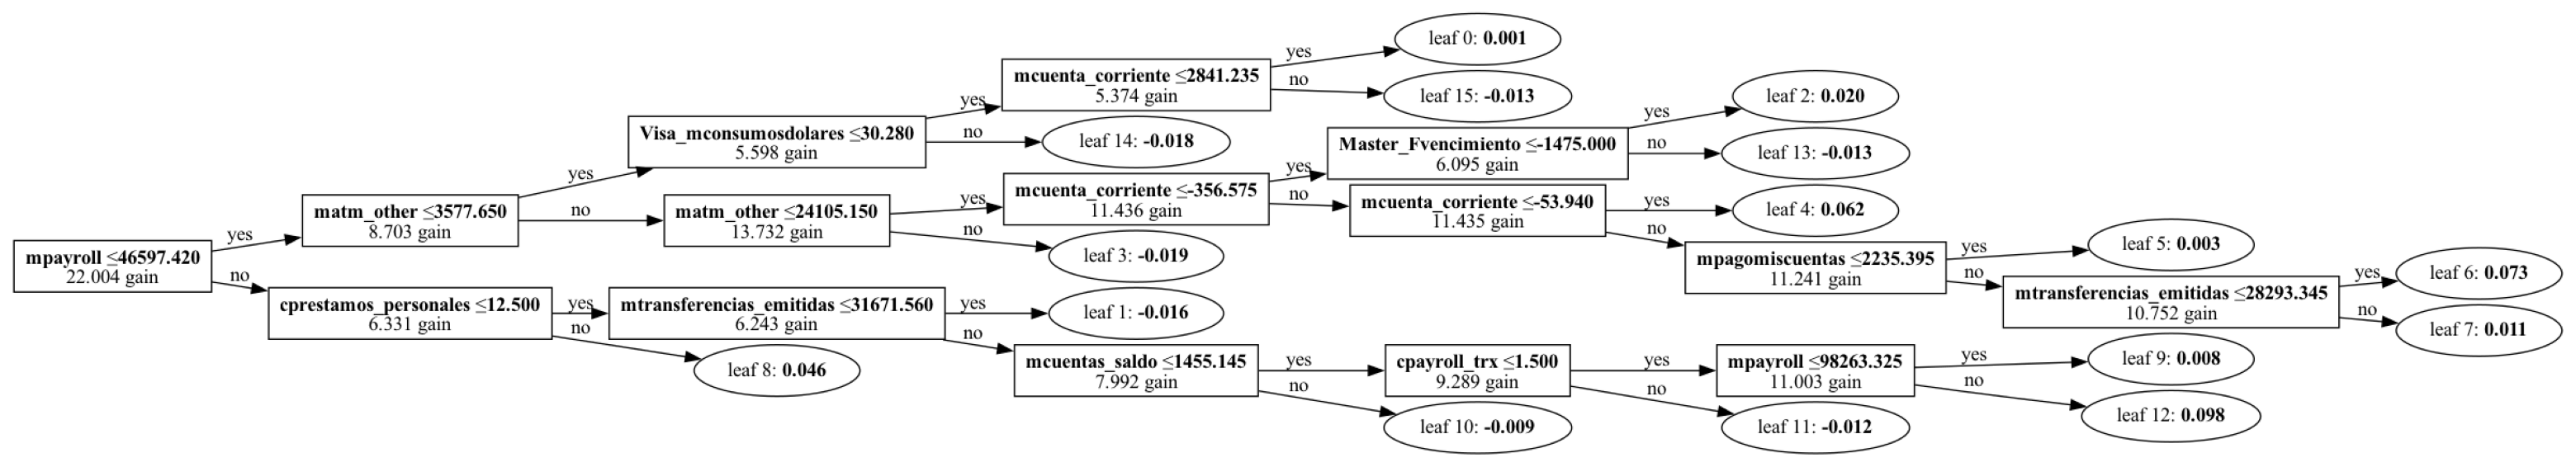

In [19]:
lgb.plot_tree(model_marzo, tree_index=154, figsize=(40, 30), show_info=['split_feature', 'threshold', 'split_gain', 'value', 'count'])

Un mes entrenado un mes anterior, no debería afectar tanto en la inferencia. Pero... y si lo usamos para entrenar, afectará los meses con los que se infiera?

## Mirando el futuro
Cerramos con las dos variables de préstamos personales juntas, usando como bins los mismos cortes que arma `psi_bins` (por `qcut`), pero esta vez comparando **Abril** (202104) contra **Junio** (202106) en lugar de Marzo contra Junio.

In [20]:
abril_data_full = data[data['foto_mes'] == 202104]
junio_data_full = data[data['foto_mes'] == 202106]

def target_por_bins_psi(variable, ref_data, act_data, buckets=10, clase_positiva='BAJA+2'):
    bins_df = psi_bins(ref_data[variable], act_data[variable], buckets=buckets)

    numeric_bins = bins_df[bins_df['Bin'] != 'Null_Values']
    parsed_edges = []
    for bin_str in numeric_bins['Bin'].tolist():
        parts = bin_str[1:-1].split(', ')
        parsed_edges.append(float(parts[0]))
        parsed_edges.append(float(parts[1]))
    cortes = sorted(set(parsed_edges))

    ref_bin = pd.cut(ref_data[variable], bins=cortes, right=True, include_lowest=True)
    act_bin = pd.cut(act_data[variable], bins=cortes, right=True, include_lowest=True)

    ref_target = (ref_data['clase_ternaria'] == clase_positiva).astype(int)
    act_target = (act_data['clase_ternaria'] == clase_positiva).astype(int)

    return pd.DataFrame({
        'count_abril': ref_target.groupby(ref_bin, observed=False).count(),
        'target_abril': ref_target.groupby(ref_bin, observed=False).sum(),
        'count_junio': act_target.groupby(act_bin, observed=False).count(),
        'target_junio': act_target.groupby(act_bin, observed=False).sum(),
    })


resumenes_prestamos = {}

for variable in ['mprestamos_personales', 'cprestamos_personales']:
    psi_value = psi(abril_data_full[variable], junio_data_full[variable])
    resumen = target_por_bins_psi(variable, abril_data_full, junio_data_full)
    resumenes_prestamos[variable] = resumen

    print(f"\n{variable} (PSI Abril vs Junio: {psi_value:.5f})")
    display(resumen)



mprestamos_personales (PSI Abril vs Junio: 0.00015)


,count_abril,target_abril,count_junio,target_junio
mprestamos_personales,,,,
"(-0.001, 11623.94]",130370,1083,131550,890
"(11623.94, 99639.182]",16624,36,16114,84
"(99639.182, 7038000.0]",16290,20,16450,124



cprestamos_personales (PSI Abril vs Junio: 0.00041)


,count_abril,target_abril,count_junio,target_junio
cprestamos_personales,,,,
"(-0.001, 1.0]",144833,1100,146593,911
"(1.0, 2.0]",6518,14,6447,10
"(2.0, 506.0]",11933,25,11074,177


Vemos un claro drift... pero como lo hubieramos detectado con los datos sin usar el target?

